In [30]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np

# Load all results
results = {}
for f in sorted(os.listdir('results_experiment1')):
    if f.endswith('.json'):
        with open(os.path.join('results_experiment1', f)) as fh:
            data = json.load(fh)
            results[data['meta_concept']] = data

# Filter out concepts that have no coordinate data
names = [n for n in results.keys() if results[n]['images_without_coords'] < results[n]['total_images']]
print(f'Loaded {len(results)} meta concepts, {len(names)} have coordinate data')

Loaded 28 meta concepts, 20 have coordinate data


In [31]:
def compute_metrics(tp, fp, tn, fn):
    """Compute accuracy, recall (TP rate), precision, and F1 from confusion matrix counts."""
    total = tp + fp + tn + fn
    acc = (tp + tn) / total if total > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return acc, recall, precision, f1


def bar_plot(names, orig, masked, title, ylabel='Value'):
    x = np.arange(len(names))
    width = 0.35
    fig, ax = plt.subplots(figsize=(max(10, len(names) * 0.6), 5))
    ax.bar(x - width/2, orig, width, label='Original')
    ax.bar(x + width/2, masked, width, label='Masked')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.legend()
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

In [32]:
# Precompute metrics for each split
splits = {
    'All Images': ('target_orig', 'target_mask'),
    'Same Class Predictions': ('same_pred_target_orig', 'same_pred_target_mask'),
    'Different Class Predictions': ('diff_pred_target_orig', 'diff_pred_target_mask'),
}

computed = {}  # computed[split_name][meta_name] = {'orig': (acc,rec,prec,f1), 'mask': ...}
for split_name, (orig_pfx, mask_pfx) in splits.items():
    computed[split_name] = {}
    for n in names:
        r = results[n]
        orig_m = compute_metrics(r[f'{orig_pfx}_tp'], r[f'{orig_pfx}_fp'],
                                 r[f'{orig_pfx}_tn'], r[f'{orig_pfx}_fn'])
        mask_m = compute_metrics(r[f'{mask_pfx}_tp'], r[f'{mask_pfx}_fp'],
                                 r[f'{mask_pfx}_tn'], r[f'{mask_pfx}_fn'])
        computed[split_name][n] = {'orig': orig_m, 'mask': mask_m}

print('Metrics computed for all splits')

Metrics computed for all splits


## Target Concept - All Images

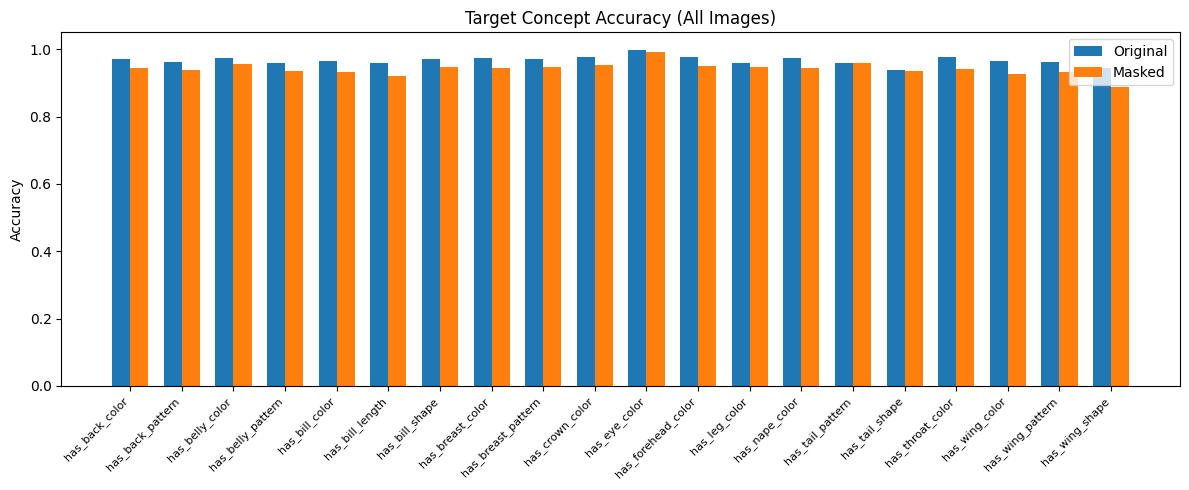

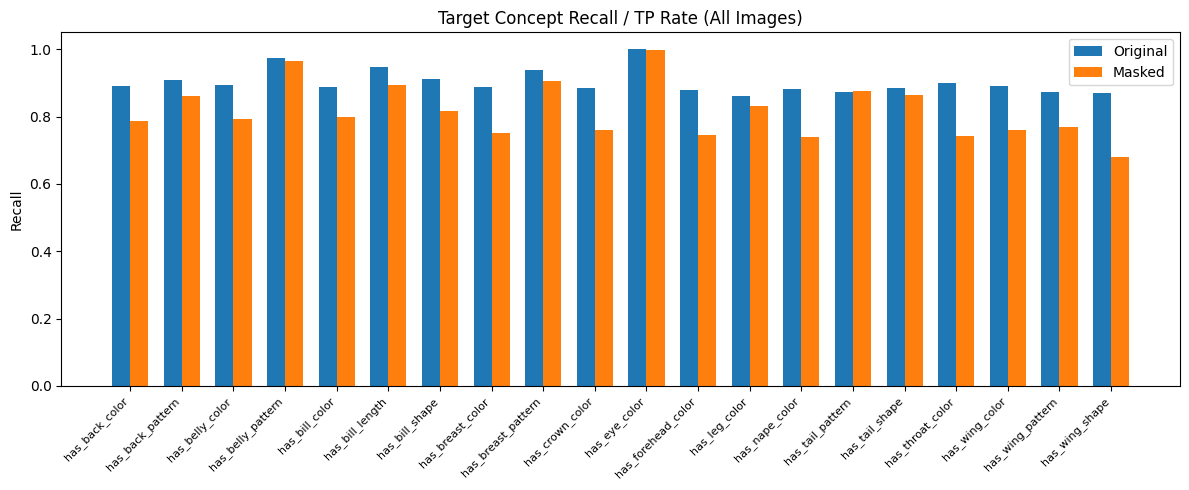

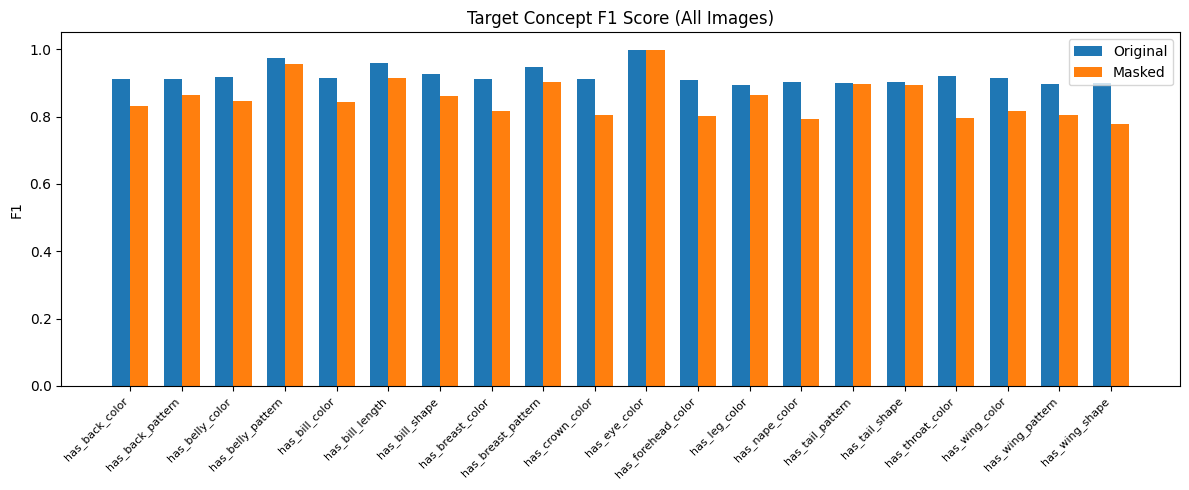

In [33]:
split = 'All Images'
bar_plot(names,
         [computed[split][n]['orig'][0] for n in names],
         [computed[split][n]['mask'][0] for n in names],
         f'Target Concept Accuracy ({split})', ylabel='Accuracy')

bar_plot(names,
         [computed[split][n]['orig'][1] for n in names],
         [computed[split][n]['mask'][1] for n in names],
         f'Target Concept Recall / TP Rate ({split})', ylabel='Recall')

bar_plot(names,
         [computed[split][n]['orig'][3] for n in names],
         [computed[split][n]['mask'][3] for n in names],
         f'Target Concept F1 Score ({split})', ylabel='F1')

## Target Concept - Same Class Predictions

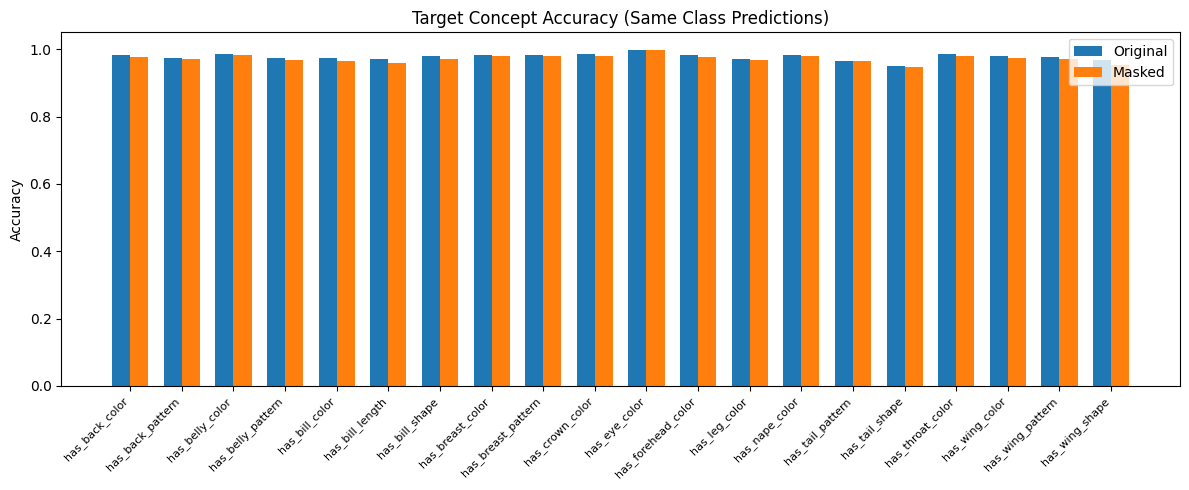

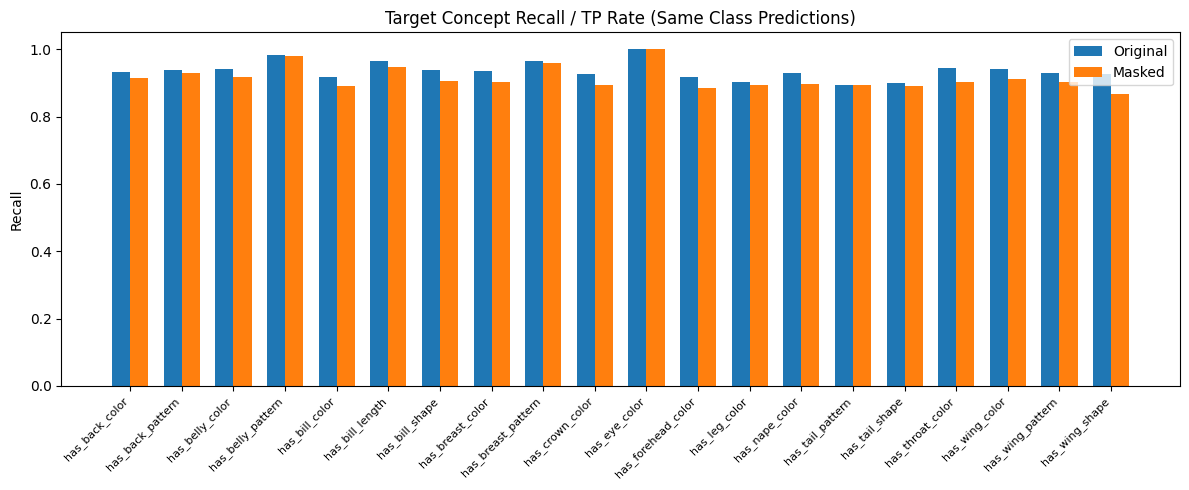

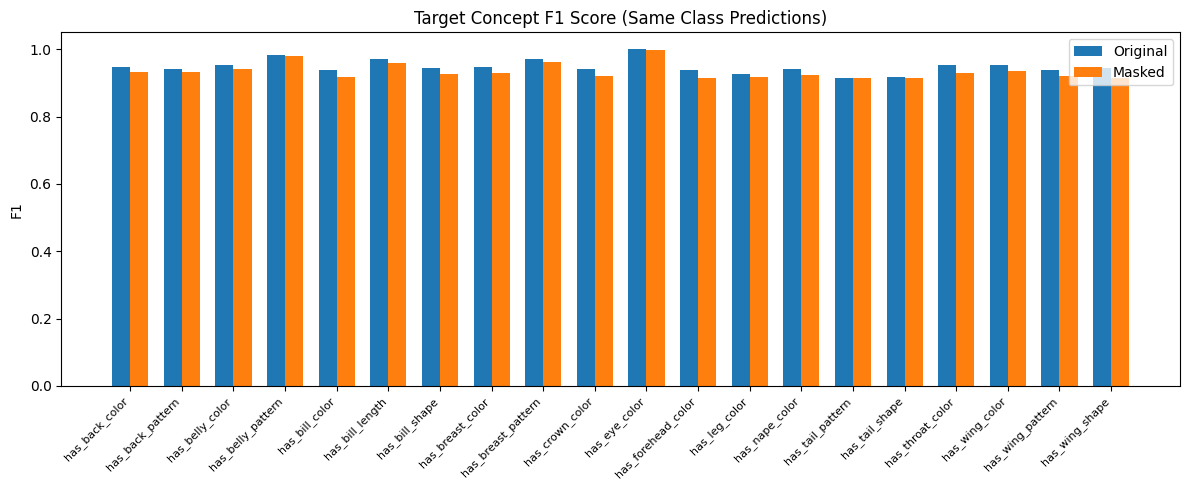

In [34]:
split = 'Same Class Predictions'
bar_plot(names,
         [computed[split][n]['orig'][0] for n in names],
         [computed[split][n]['mask'][0] for n in names],
         f'Target Concept Accuracy ({split})', ylabel='Accuracy')

bar_plot(names,
         [computed[split][n]['orig'][1] for n in names],
         [computed[split][n]['mask'][1] for n in names],
         f'Target Concept Recall / TP Rate ({split})', ylabel='Recall')

bar_plot(names,
         [computed[split][n]['orig'][3] for n in names],
         [computed[split][n]['mask'][3] for n in names],
         f'Target Concept F1 Score ({split})', ylabel='F1')

## Target Concept - Different Class Predictions

In [ ]:
# Category sizes (uses first concept since total/same/diff counts are per-concept based on their coords)
for n in names:
    total = results[n]['same_class_pred_count'] + results[n]['diff_class_pred_count'] + results[n]['images_without_coords']
    same = results[n]['same_class_pred_count']
    diff = results[n]['diff_class_pred_count']
    no_coords = results[n]['images_without_coords']
    used = same + diff
    print(f'{n}: {same} same, {diff} different, {no_coords} no coords ({used}/{total} used)')

# Mean concept accuracy across all concepts per split
print()
for split_name in splits:
    orig_accs = [computed[split_name][n]['orig'][0] for n in names]
    mask_accs = [computed[split_name][n]['mask'][0] for n in names]
    print(f'{split_name}: mean orig acc = {np.mean(orig_accs):.4f}, mean masked acc = {np.mean(mask_accs):.4f}')

# Mean class accuracy
class_orig = np.mean([results[n]['4_class_all_images_original'] for n in names])
class_mask = np.mean([results[n]['4_class_all_images_masked'] for n in names])
print(f'Class Accuracy: mean orig = {class_orig:.4f}, mean masked = {class_mask:.4f}')

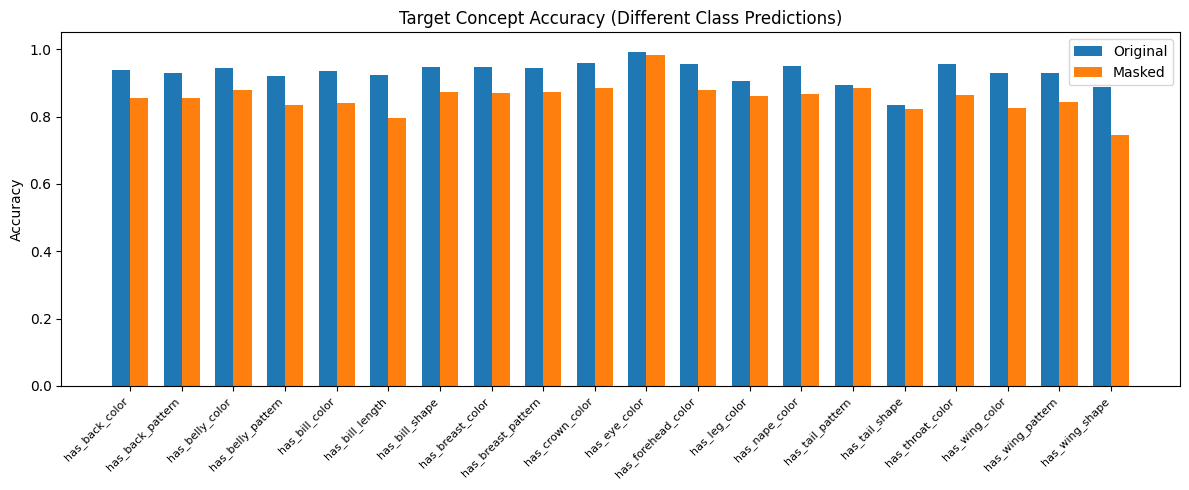

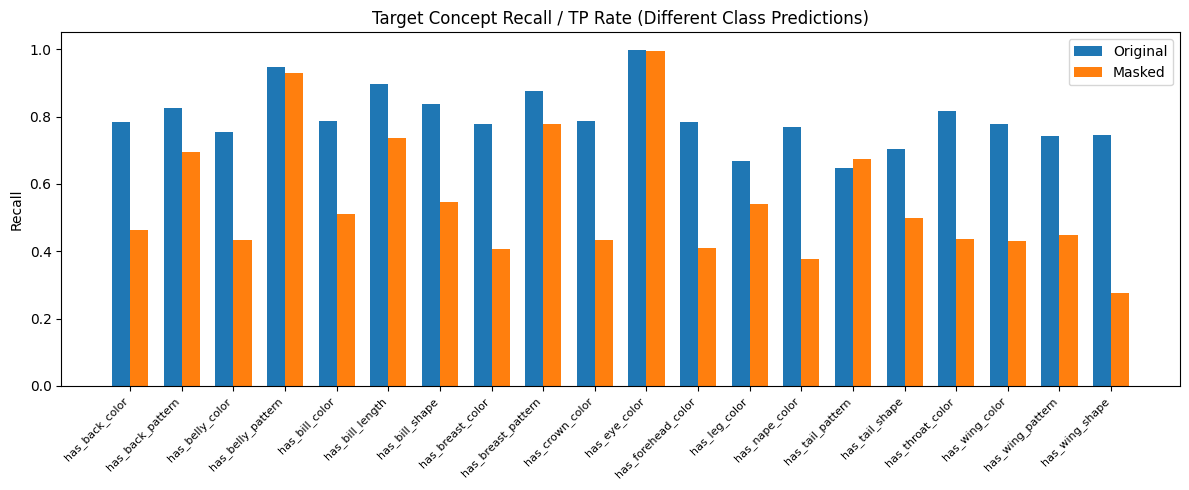

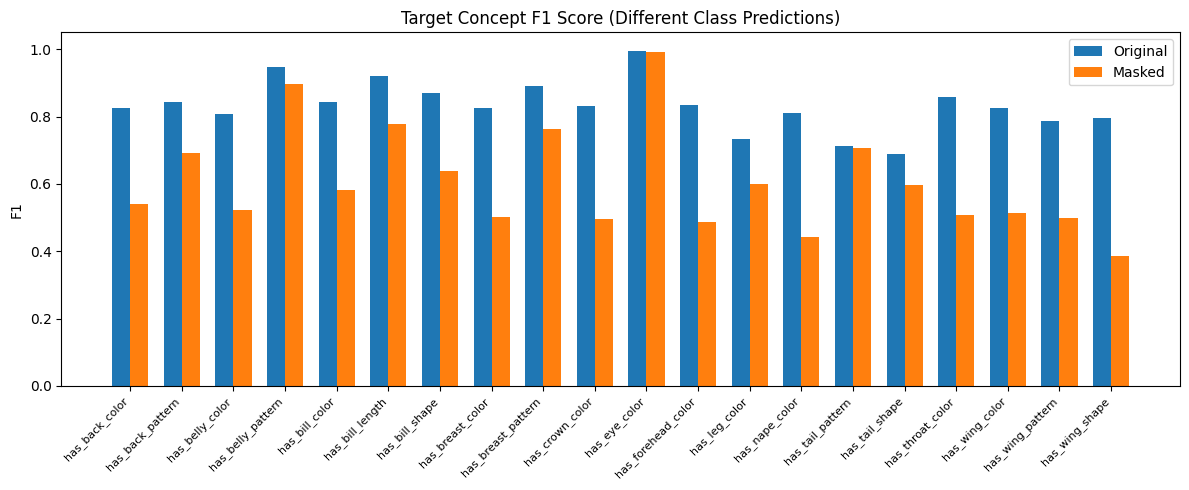

In [36]:
split = 'Different Class Predictions'
bar_plot(names,
         [computed[split][n]['orig'][0] for n in names],
         [computed[split][n]['mask'][0] for n in names],
         f'Target Concept Accuracy ({split})', ylabel='Accuracy')

bar_plot(names,
         [computed[split][n]['orig'][1] for n in names],
         [computed[split][n]['mask'][1] for n in names],
         f'Target Concept Recall / TP Rate ({split})', ylabel='Recall')

bar_plot(names,
         [computed[split][n]['orig'][3] for n in names],
         [computed[split][n]['mask'][3] for n in names],
         f'Target Concept F1 Score ({split})', ylabel='F1')

## Delta Plots - Drop in Accuracy, Recall, and F1

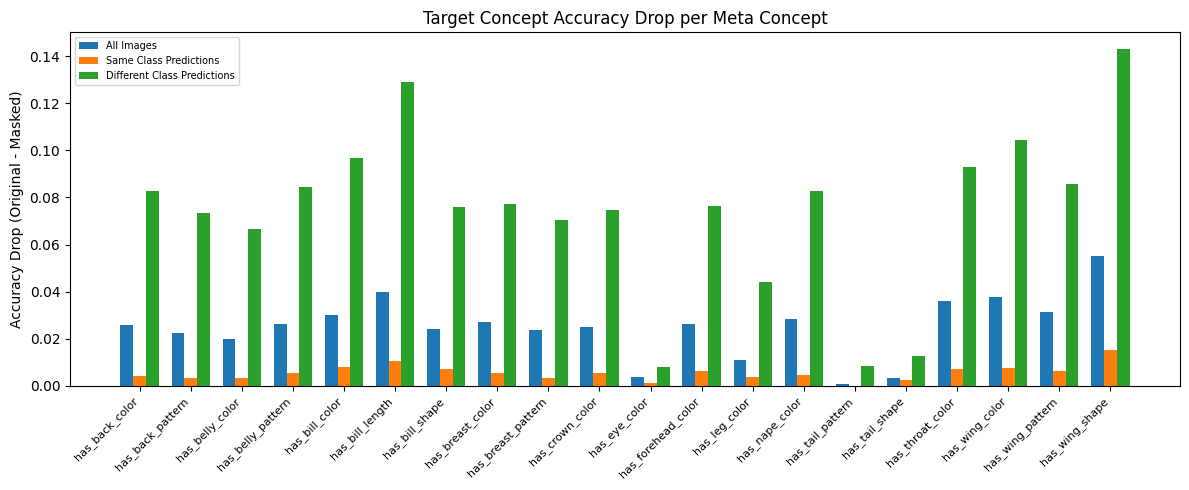

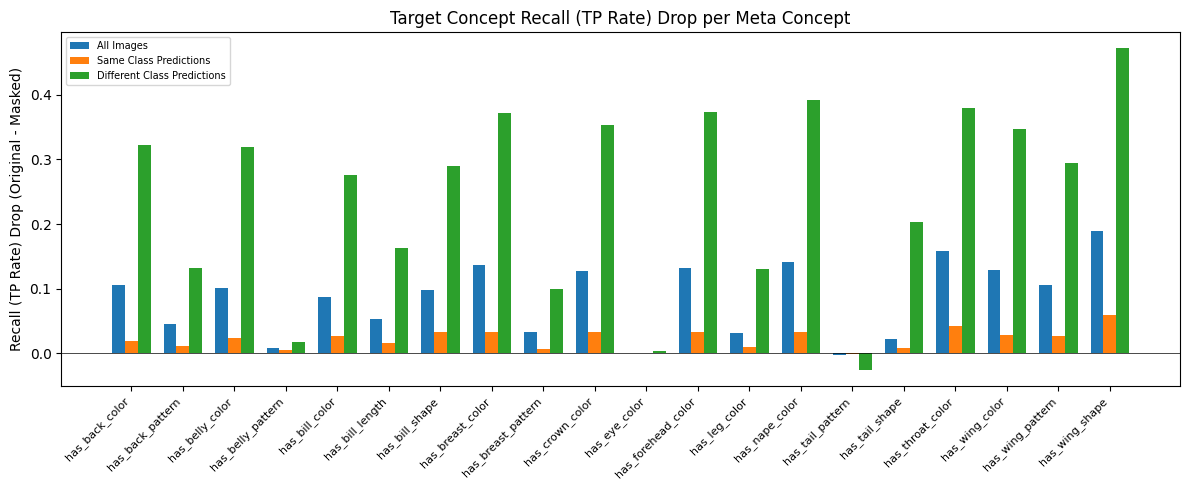

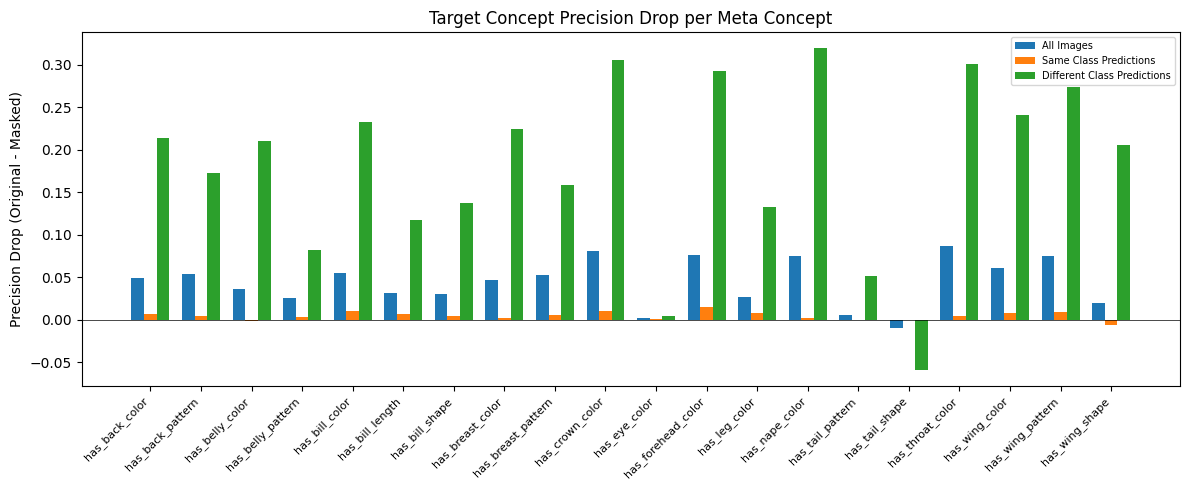

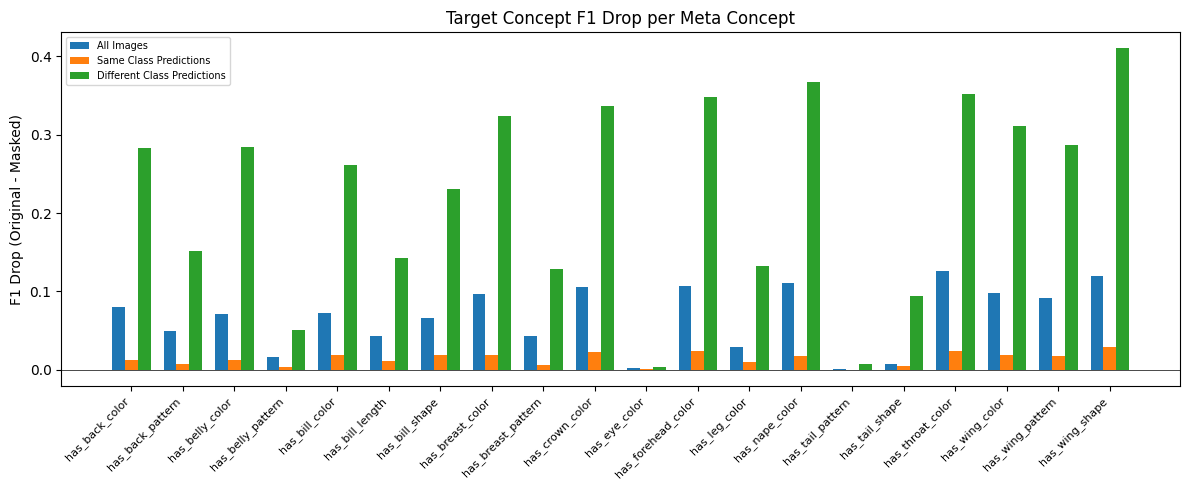

In [37]:
metric_names = ['Accuracy', 'Recall (TP Rate)', 'Precision', 'F1']

for mi, mname in enumerate(metric_names):
    fig, ax = plt.subplots(figsize=(max(10, len(names) * 0.6), 5))
    x = np.arange(len(names))
    width = 0.25

    for si, split in enumerate(splits.keys()):
        deltas = [computed[split][n]['orig'][mi] - computed[split][n]['mask'][mi] for n in names]
        ax.bar(x + si * width, deltas, width, label=split)

    ax.set_ylabel(f'{mname} Drop (Original - Masked)')
    ax.set_title(f'Target Concept {mname} Drop per Meta Concept')
    ax.set_xticks(x + width)
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=7)
    ax.axhline(y=0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

## Class Accuracy

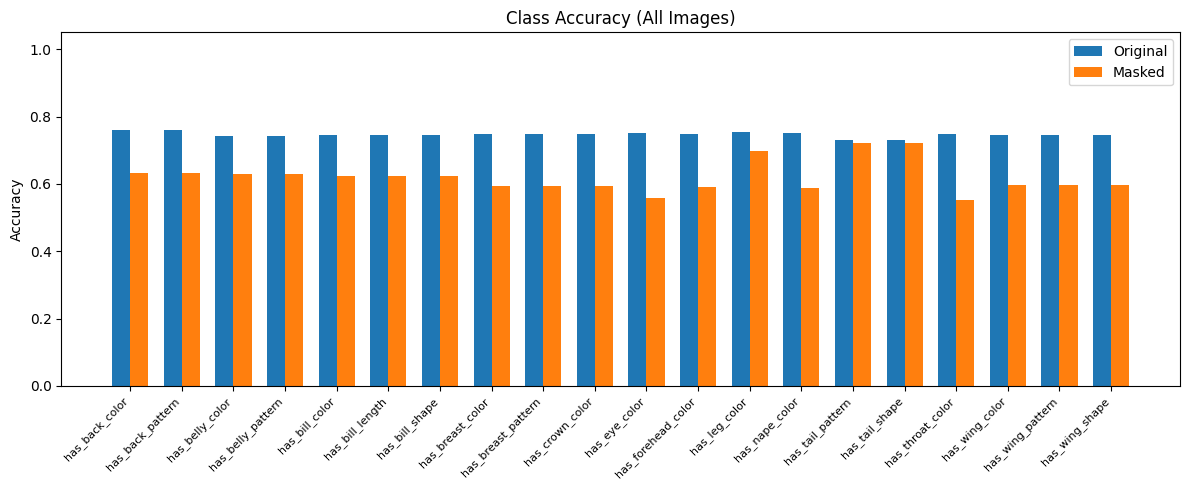

In [38]:
bar_plot(names,
         [results[n]['4_class_all_images_original'] for n in names],
         [results[n]['4_class_all_images_masked'] for n in names],
         'Class Accuracy (All Images)', ylabel='Accuracy')